## PCA Analysis on Breast Cancer Dataset
Principal Component Analysis for Dimensionality Reduction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8')

## Load and Prepare Data

In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("\nFeature Names:")
for i, feature in enumerate(data.feature_names):
    print(f"{i+1}. {feature}")

Dataset Shape: (569, 30)

Feature Names:
1. mean radius
2. mean texture
3. mean perimeter
4. mean area
5. mean smoothness
6. mean compactness
7. mean concavity
8. mean concave points
9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


## Feature Correlation Analysis

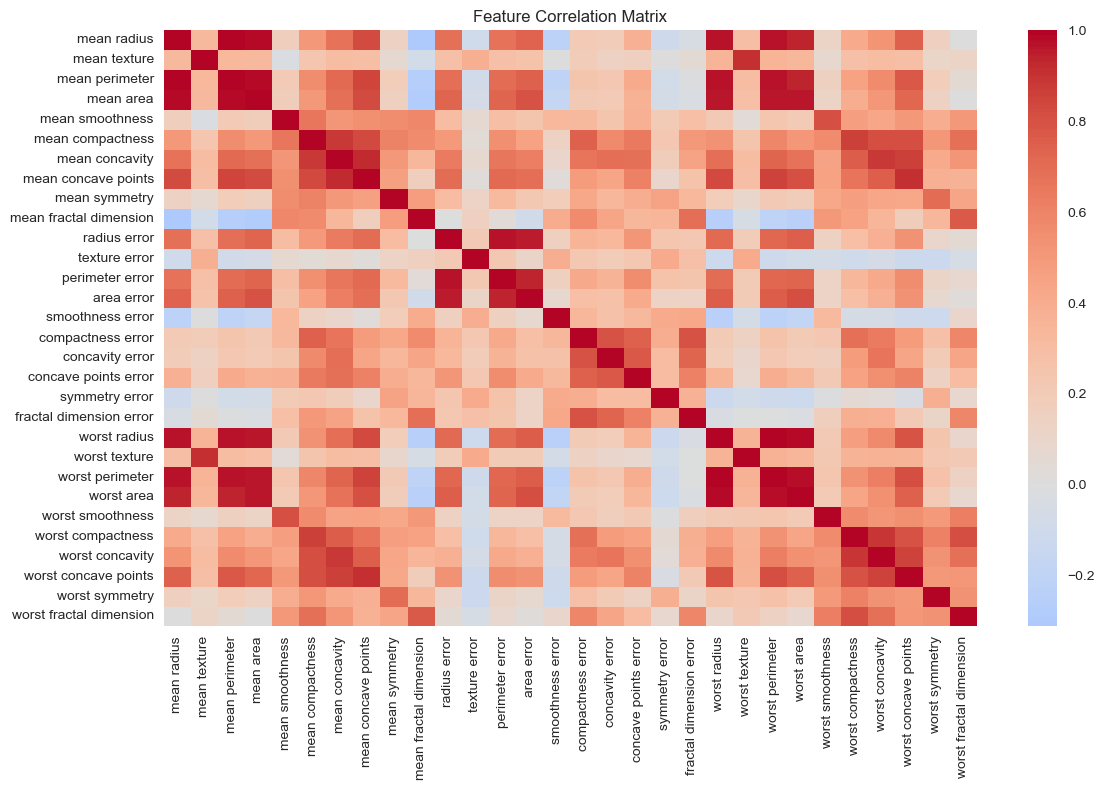

In [3]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Data Preprocessing and PCA

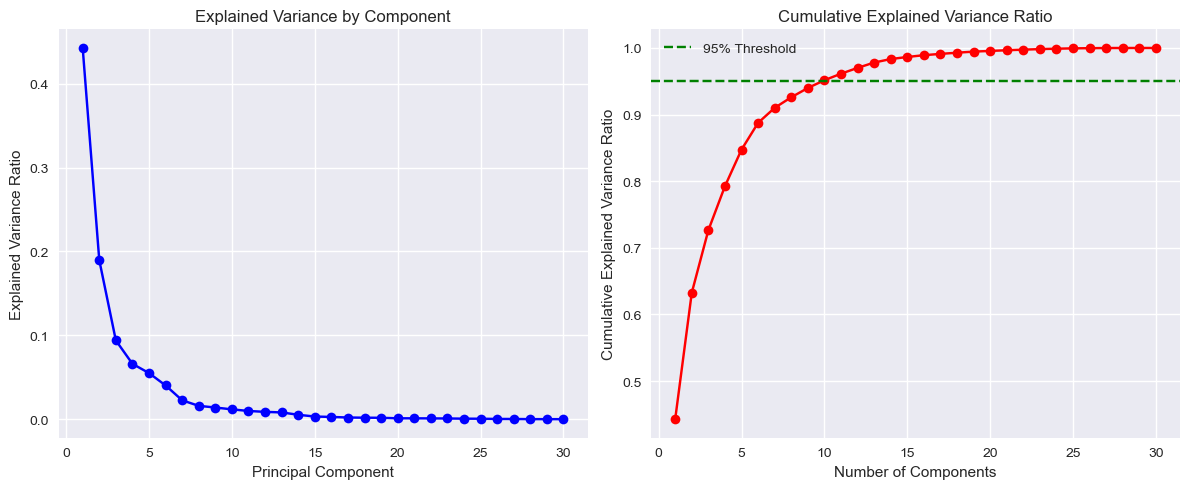


Variance Explained by Each Component:
PC1: 0.4427 (0.4427 cumulative)
PC2: 0.1897 (0.6324 cumulative)
PC3: 0.0939 (0.7264 cumulative)
PC4: 0.0660 (0.7924 cumulative)
PC5: 0.0550 (0.8473 cumulative)
PC6: 0.0402 (0.8876 cumulative)
PC7: 0.0225 (0.9101 cumulative)
PC8: 0.0159 (0.9260 cumulative)
PC9: 0.0139 (0.9399 cumulative)
PC10: 0.0117 (0.9516 cumulative)
PC11: 0.0098 (0.9614 cumulative)
PC12: 0.0087 (0.9701 cumulative)
PC13: 0.0080 (0.9781 cumulative)
PC14: 0.0052 (0.9834 cumulative)
PC15: 0.0031 (0.9865 cumulative)
PC16: 0.0027 (0.9892 cumulative)
PC17: 0.0020 (0.9911 cumulative)
PC18: 0.0018 (0.9929 cumulative)
PC19: 0.0016 (0.9945 cumulative)
PC20: 0.0010 (0.9956 cumulative)
PC21: 0.0010 (0.9966 cumulative)
PC22: 0.0009 (0.9975 cumulative)
PC23: 0.0008 (0.9983 cumulative)
PC24: 0.0006 (0.9989 cumulative)
PC25: 0.0005 (0.9994 cumulative)
PC26: 0.0003 (0.9997 cumulative)
PC27: 0.0002 (0.9999 cumulative)
PC28: 0.0001 (1.0000 cumulative)
PC29: 0.0000 (1.0000 cumulative)
PC30: 0.0000 

In [4]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Plot explained variance ratio
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'ro-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Print variance explained by each component
print("\nVariance Explained by Each Component:")
for i, var in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {var:.4f} ({cumulative_variance_ratio[i]:.4f} cumulative)")

## Select Optimal Number of Components

In [5]:
# Find number of components for 95% variance
n_components = np.where(cumulative_variance_ratio >= 0.95)[0][0] + 1
print(f"\nNumber of components needed for 95% variance: {n_components}")

# Reduce dimensionality
pca_final = PCA(n_components=n_components)
X_reduced = pca_final.fit_transform(X_scaled)
print(f"\nReduced data shape: {X_reduced.shape}")

# Create dataframe with reduced features
X_reduced_df = pd.DataFrame(
    X_reduced,
    columns=[f'PC{i+1}' for i in range(n_components)]
)


Number of components needed for 95% variance: 10

Reduced data shape: (569, 10)


## Visualize First Two Principal Components

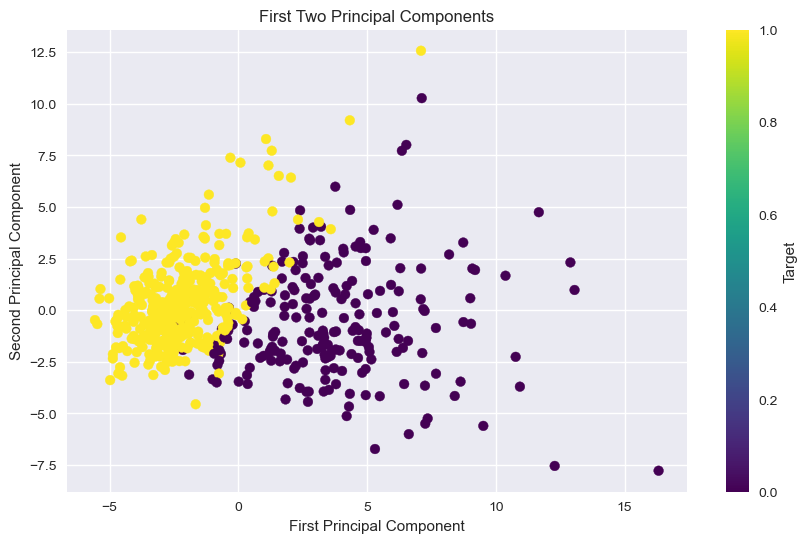

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('First Two Principal Components')
plt.colorbar(label='Target')
plt.show()

## Feature Importance Analysis

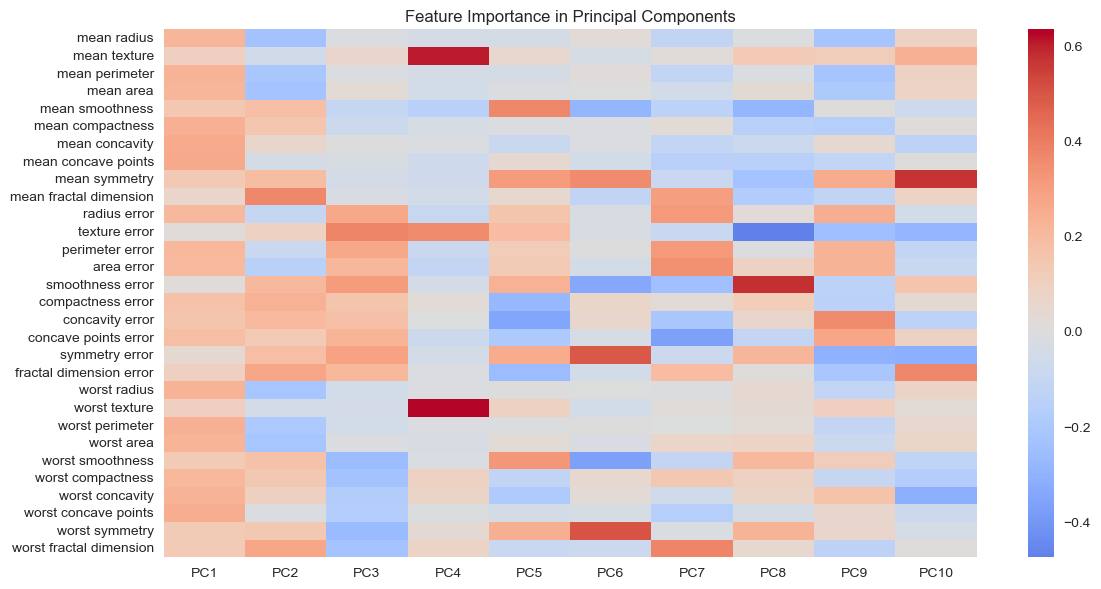


Top 5 Features for First Two Principal Components:

PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
Name: PC1, dtype: float64

PC2:
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
mean radius                0.233857
compactness error          0.232716
Name: PC2, dtype: float64


In [7]:
# Get feature importance from PCA components
components_df = pd.DataFrame(
    pca_final.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=data.feature_names
)

plt.figure(figsize=(12, 6))
sns.heatmap(components_df, cmap='coolwarm', center=0)
plt.title('Feature Importance in Principal Components')
plt.tight_layout()
plt.show()

# Print top features for first two components
print("\nTop 5 Features for First Two Principal Components:")
for i in range(2):
    pc = components_df[f'PC{i+1}'].abs()
    print(f"\nPC{i+1}:")
    print(pc.sort_values(ascending=False).head())

## Model Evaluation with Reduced Dimensions

Model Performance with Reduced Dimensions:
----------------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



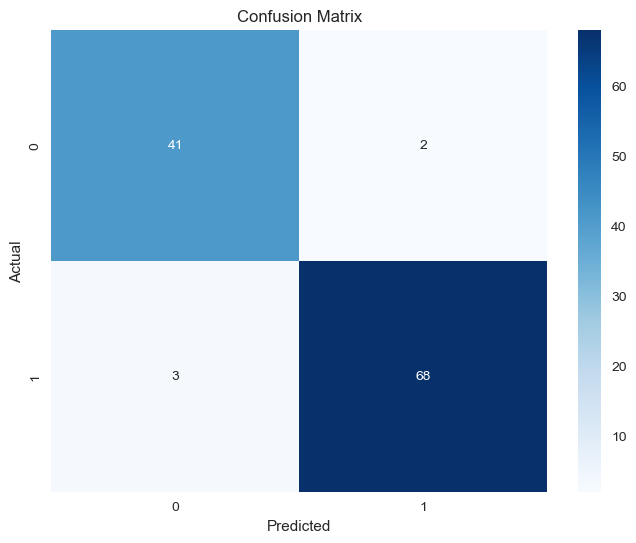

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Train a simple classifier (Random Forest)
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Print evaluation metrics
print("Model Performance with Reduced Dimensions:")
print("-" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Comparison with Original Dimensions